# Post 09: What Do Free-Energy Estimators Assume?

This notebook is the presentation layer for the ninth tutorial. The reusable FEP, BAR, overlap, ESS, and figure logic lives in `src/kups_md_tutorials/`.


In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.estimators import load_estimator_summary
from kups_md_tutorials.figures import generate_post09_figures

## Configuration

The smoke and full profiles compare two-state Gaussian systems with known free-energy offsets. Increasing the mean shift lowers overlap while keeping the true free energy fixed.

In [3]:
for profile in ["smoke", "full"]:
    print(f"--- {profile} ---")
    print(json.dumps(json.loads(Path(f"configs/post-09/{profile}.json").read_text()), indent=2))

--- smoke ---
{
  "post": "09",
  "profile": "smoke",
  "title": "What Do Free-Energy Estimators Assume?",
  "estimator_experiment": {
    "temperature": 1.0,
    "sample_count": 4000,
    "seed": 2026071409,
    "cases": [
      {
        "name": "good_overlap",
        "mean_shift": 0.5,
        "true_delta_f": 0.8
      },
      {
        "name": "poor_overlap",
        "mean_shift": 2.5,
        "true_delta_f": 0.8
      }
    ]
  },
  "multistate_overlap": {
    "sample_count_per_window": 1200,
    "seed": 2026071909,
    "force_constant": 12.0,
    "domain_min": -3.0,
    "domain_max": 3.0,
    "bin_width": 0.1,
    "protocols": [
      {
        "name": "dense_bridge",
        "window_centers": [
          -2.0,
          -1.2,
          -0.6,
          0.0,
          0.6,
          1.2,
          2.0
        ]
      },
      {
        "name": "sparse_bridge",
        "window_centers": [
          -2.0,
          2.0
        ]
      }
    ]
  }
}
--- full ---
{
  "post": "09",
 

## Committed Results

The summary reports forward FEP, reverse FEP, BAR, overlap coefficients, effective sample size fractions, and a multi-state bridge diagnostic. The bridge diagnostic compares connected dense windows with endpoint-only sparse windows to make the WHAM/MBAR overlap-network assumption visible.


In [4]:
summary = load_estimator_summary(Path("results/post-09/full/estimator_summary.json"))
for case in summary.cases:
    print(case.case, "overlap=", round(case.overlap_coefficient, 3), "forward FEP error=", round(case.forward_fep_error, 3), "BAR error=", round(case.bar_error, 3), "ESS=", round(case.forward_weight_ess_fraction, 4))
if summary.multistate_protocols:
    print("\nMulti-state bridge diagnostics")
    for protocol in summary.multistate_protocols:
        print(protocol.protocol, "windows=", protocol.window_count, "min adjacent overlap=", round(protocol.min_adjacent_overlap, 4), "disconnected edges=", protocol.disconnected_edges, "support-aware PMF RMSE=", round(protocol.pmf_rmse_vs_true, 3))


good_overlap overlap= 0.803 forward FEP error= -0.002 BAR error= 0.0 ESS= 0.779
marginal_overlap overlap= 0.453 forward FEP error= 0.005 BAR error= 0.008 ESS= 0.0966
poor_overlap overlap= 0.134 forward FEP error= 0.047 BAR error= 0.033 ESS= 0.0027

Multi-state bridge diagnostics
dense_bridge windows= 7 min adjacent overlap= 0.1844 disconnected edges= 0 support-aware PMF RMSE= 1.303
sparse_bridge windows= 2 min adjacent overlap= 0.0 disconnected edges= 1 support-aware PMF RMSE= 3.314


## Figure

The full-profile figure is regenerated from committed compact outputs.

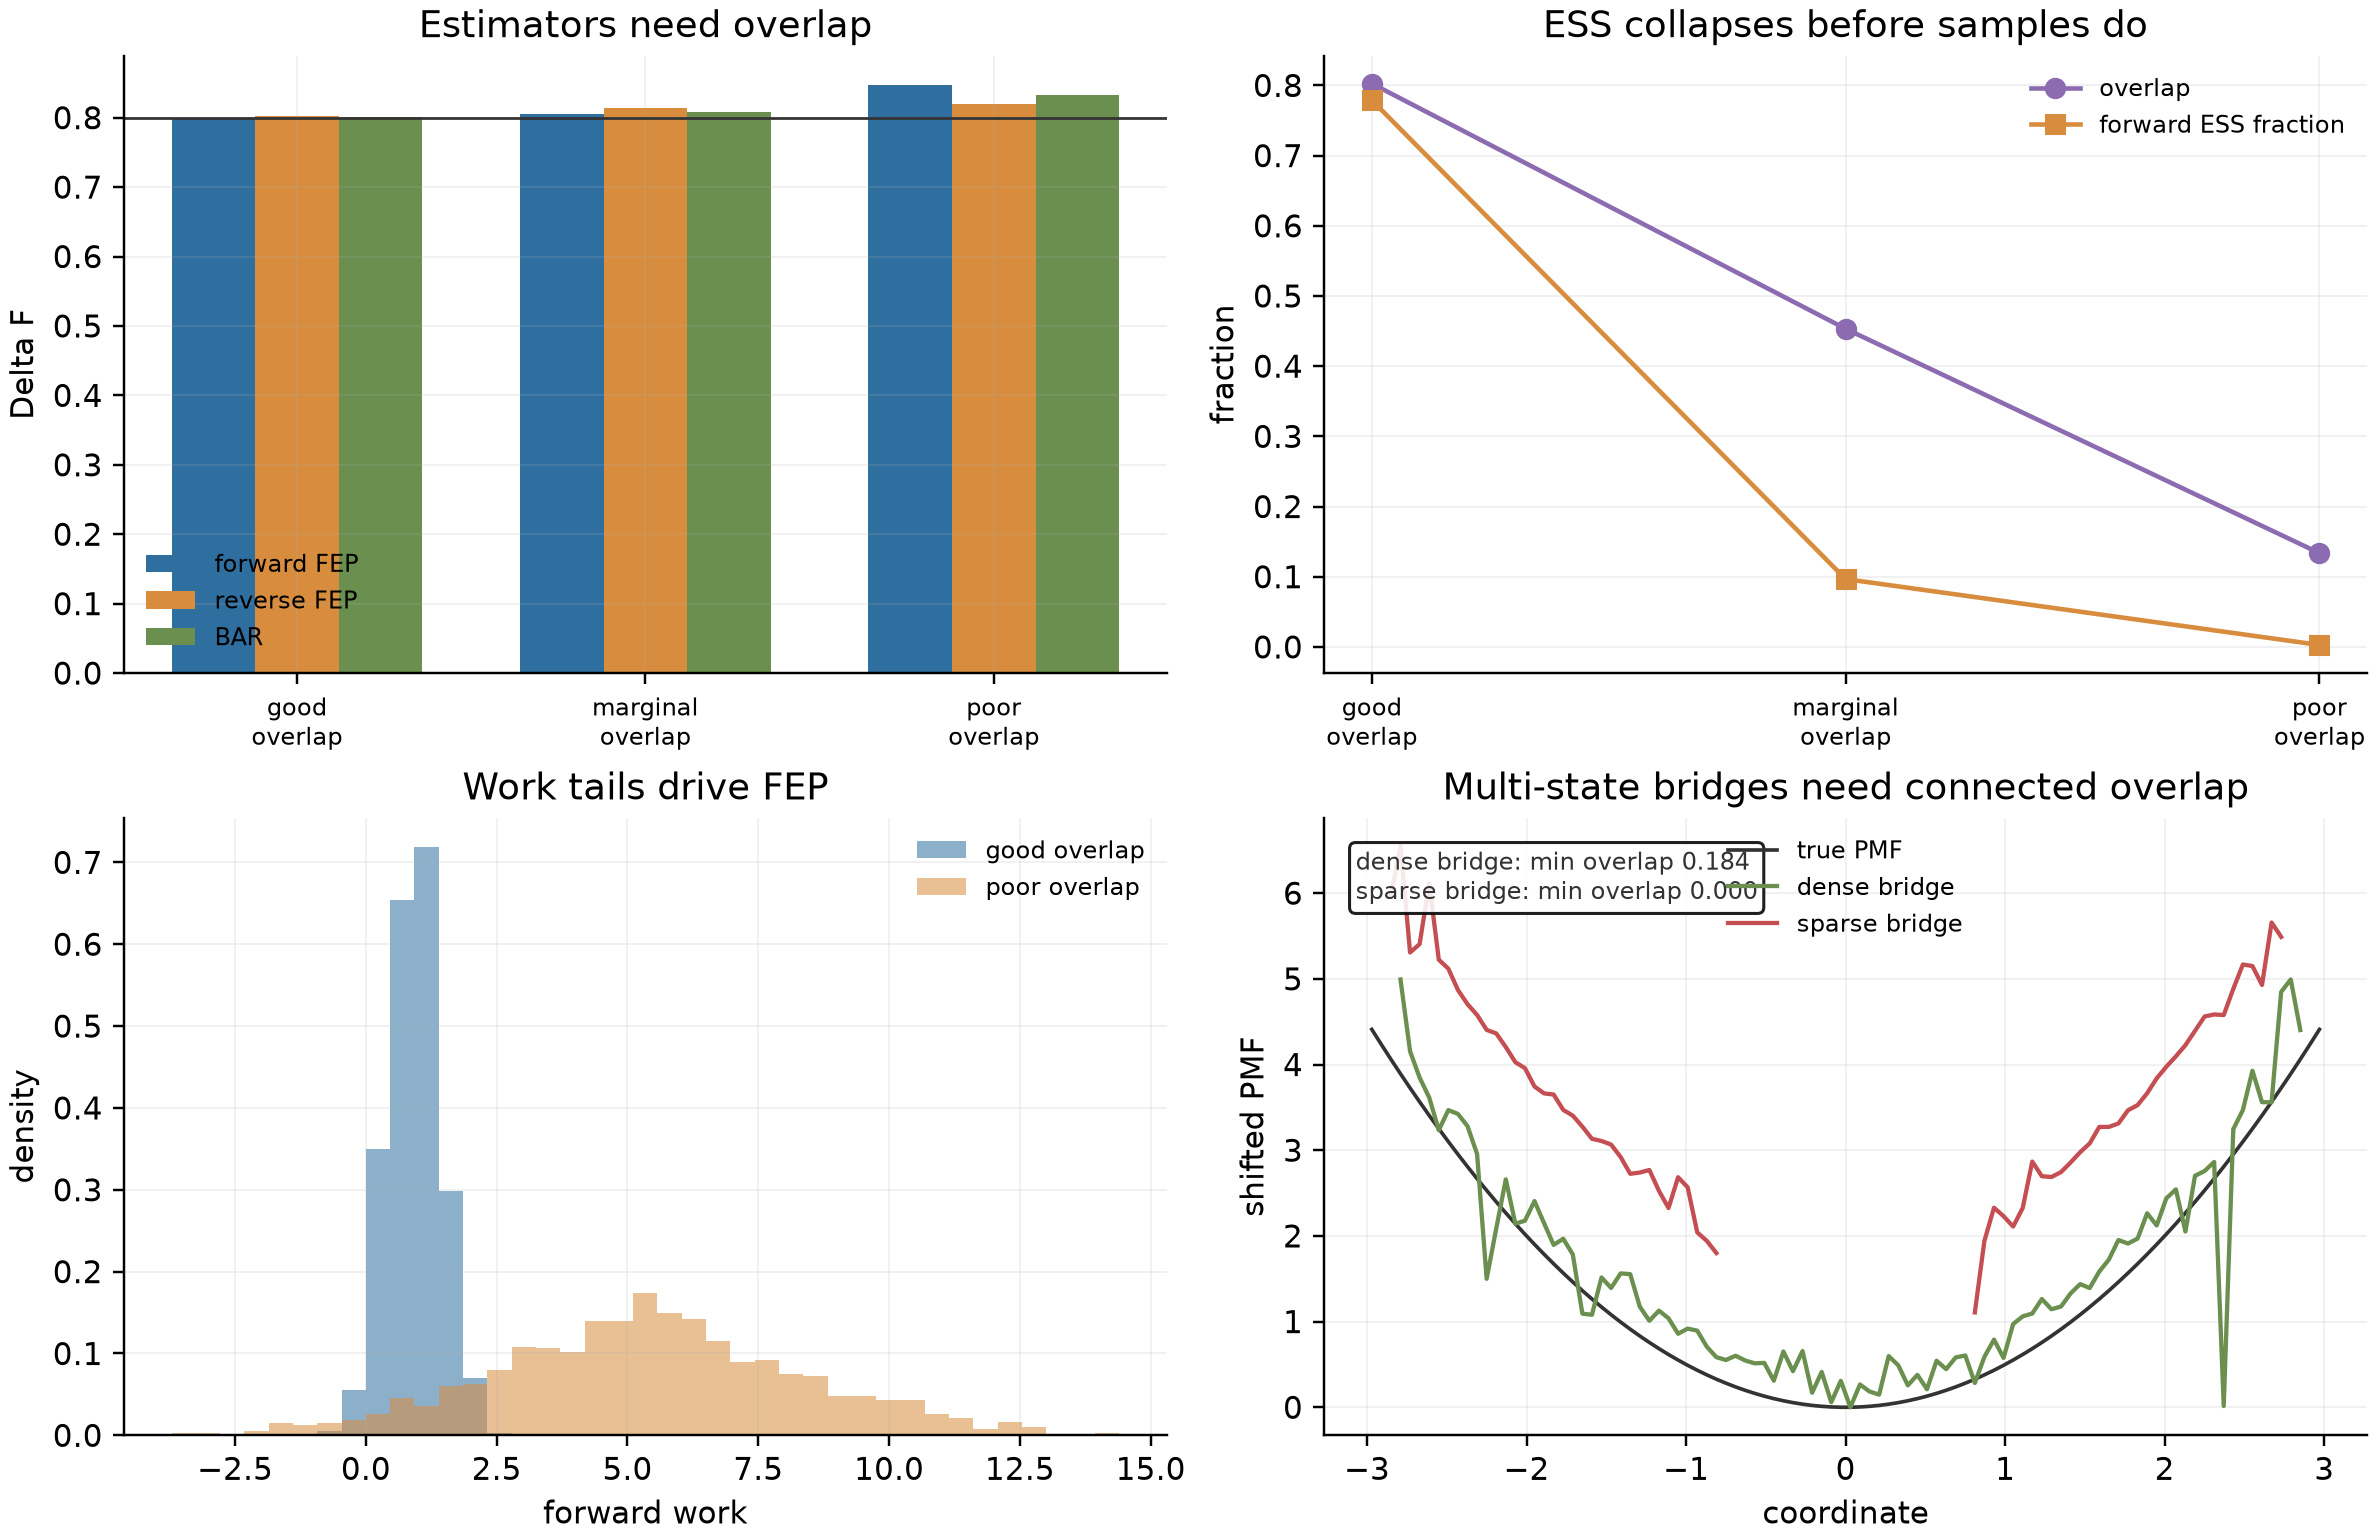

In [5]:
generate_post09_figures(
    result_dir=Path("results/post-09/full"),
    figure_dir=Path("figures/post-09"),
    snapshot_dir=Path("snapshots/post-09"),
    name="estimator_diagnostics_full",
)
display(Image(filename="figures/post-09/estimator_diagnostics_full.png"))